# DL Final Project -- MLP for YouTube View Count Prediction

## Goal

Build a MLP to predict **log(1 + view_count)** of YouTube videos.

## Input Features (6)

1. `subscriber_count` — 頻道總訂閱數
2. `video_duration_sec` — 影片長度（秒）
3. `categoryId` — 影片分類 ID（排除 10）
4. `published_at` — 發布時間（轉為數值特徵）
5. `tag_count` — tags 數量
6. `description_length` — description 字元長度

## Target

- `log(1 + view_count)`

## Settings

- Train / Test split: 80% / 20%
- Epochs: 400
- Batch size: 64

## Part 1

Clone the dataset from GitHub and import necessary libraries.

In [1]:
!git clone https://github.com/Anson-ntuim/DL-Final.git

Cloning into 'DL-Final'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 17 (delta 3), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 10.93 MiB | 6.25 MiB/s, done.
Resolving deltas: 100% (3/3), done.


## Part 2

Import libraries.

In [2]:
# Model
import os
import copy
import torch
import torch.nn as nn
from torch.optim.optimizer import Optimizer

# Dataset
from torch.utils.data import Dataset, DataLoader

# Pre-processing
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split

## Part 3

Global variables / hyperparameters.

In [3]:
batch_size = 64
num_epoch = 200
learning_rate = 0.0005
train_ratio = 0.8
val_ratio = 0.15      # 從 train 再切 15% 做 validation
seed = 42

LOSS_TYPE = 'huber'   # 'huber' or 'mse'
HUBER_BETA = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Part 4

Data loading and preprocessing.

- Parse ISO 8601 duration → seconds
- Parse `published_at` → hour of day + day of week (cyclic encoding)
- Remove rows where `categoryId == 10`
- Fill missing values (tag_count → 0, description_length → 0)
- StandardScaler normalization on all features
- Target: `log(1 + view_count)`

In [4]:
# ── 工具函式 ────────────────────────────────────────────────

def parse_iso8601_duration(duration_str):
    """ISO 8601 duration (e.g. PT1H2M3S) → seconds (int)"""
    if not isinstance(duration_str, str):
        return 0
    pattern = r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    match = re.match(pattern, duration_str)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s


def parse_published_at(dt_str):
    """ISO 8601 datetime → (hour_of_day, day_of_week)"""
    try:
        dt = datetime.fromisoformat(dt_str.replace('Z', '+00:00'))
        return dt.hour, dt.weekday()   # 0-23, 0-6
    except Exception:
        return 0, 0


class StandardScaler:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0) + 1e-8
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_


# ── 讀取資料 ────────────────────────────────────────────────
data_dir = 'DL-Final/data'
files = os.listdir(data_dir)

csv_files  = [f for f in files if f.endswith('.csv')]
json_files = [f for f in files if f.endswith('.json')]

if csv_files:
    df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
elif json_files:
    df = pd.read_json(os.path.join(data_dir, json_files[0]))
else:
    raise FileNotFoundError('找不到資料檔')

print(f'Loaded data shape={df.shape}')

Loaded data shape=(34383, 27)


/tmp/ipykernel_1886/258507128.py:43: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(data_dir, csv_files[0]))


In [5]:
# ── 特徵工程 (優化版) ────────────────────────────────────────────────

# 1. 移除 category_id == 10
if 'category_id' in df.columns:
    df = df[df['category_id'] != 10].copy()

# 2. 處理類別型特徵：One-hot Encoding for category_id
df['category_id'] = df['category_id'].astype(str)
df_encoded = pd.get_dummies(df, columns=['category_id'], prefix='cat')

# 3. 數值特徵轉換
if 'duration_iso8601' in df.columns:
    df_encoded['video_duration_sec'] = df['duration_iso8601'].apply(parse_iso8601_duration)

if 'published_at' in df.columns:
    df_encoded[['pub_hour', 'pub_weekday']] = df['published_at'].apply(
        lambda x: pd.Series(parse_published_at(str(x)))
    )

    # 週期性編碼 (Cyclic Encoding) for pub_hour and pub_weekday
    # pub_hour (0-23)
    df_encoded['pub_hour_sin'] = np.sin(2 * np.pi * df_encoded['pub_hour'] / 24.0)
    df_encoded['pub_hour_cos'] = np.cos(2 * np.pi * df_encoded['pub_hour'] / 24.0)
    # pub_weekday (0-6, Mon-Sun)
    df_encoded['pub_weekday_sin'] = np.sin(2 * np.pi * df_encoded['pub_weekday'] / 7.0)
    df_encoded['pub_weekday_cos'] = np.cos(2 * np.pi * df_encoded['pub_weekday'] / 7.0)


#subscriber_count太大，要壓縮
df_encoded['subscriber_count'] = np.log1p(df_encoded['subscriber_count'])
df_encoded['video_duration_sec'] = np.log1p(df_encoded['video_duration_sec'])
df_encoded['description_length'] = np.log1p(df_encoded['description_length'])
df_encoded['channel_view_count'] = np.log1p(df_encoded['channel_view_count'])
df_encoded['channel_video_count'] = np.log1p(df_encoded['channel_video_count'])

df['days_since_published'] = df['published_at'].apply(
    lambda x: (datetime.now(timezone.utc) -
               datetime.fromisoformat(str(x).replace('Z','+00:00'))).days
    if 'T' in str(x) else 0
)
df_encoded['days_since_published'] = np.log1p(df['days_since_published'])

# 4. 建立特徵清單 (包含 One-hot 後的欄位)
CAT_COLS = [col for col in df_encoded.columns if col.startswith('cat_')]
NUM_COLS = ['subscriber_count', 'video_duration_sec', 'tags_count', 'description_length',
            'pub_hour_sin', 'pub_hour_cos', 'pub_weekday_sin', 'pub_weekday_cos','days_since_published',
            'channel_view_count','channel_video_count']
FEATURE_COLS = CAT_COLS + NUM_COLS

X = df_encoded[FEATURE_COLS].values.astype(np.float32)
input_dim = X.shape[1] # 更新輸入維度

# target: log(1 + view_count)
view_col = 'view_count' if 'view_count' in df.columns else 'viewCount'
y = np.log1p(df[view_col].values.astype(np.float32))


print(f'New Feature matrix shape: {X.shape} (One-hot and Cyclic Encoding included)')
print(f'Target range: [{y.min():.2f}, {y.max():.2f}]')
display(df_encoded[FEATURE_COLS].head(10))

New Feature matrix shape: (34383, 25) (One-hot and Cyclic Encoding included)
Target range: [0.00, 17.06]


,cat_1,cat_15,cat_17,cat_19,cat_2,cat_20,cat_22,cat_23,cat_24,cat_25,...,video_duration_sec,tags_count,description_length,pub_hour_sin,pub_hour_cos,pub_weekday_sin,pub_weekday_cos,days_since_published,channel_view_count,channel_video_count
0,False,False,False,True,False,False,False,False,False,False,...,5.789960,0,3.583519,0.866025,0.500000,0.000000,1.000000,6.280396,16.097106,8.523374
1,False,False,False,False,False,True,False,False,False,False,...,9.770870,0,5.375278,-0.965926,-0.258819,-0.781831,0.623490,4.077537,17.034060,6.061457
2,False,False,False,False,False,False,True,False,False,False,...,3.465736,0,5.192957,0.707107,0.707107,-0.433884,-0.900969,5.575949,13.447042,4.127134
3,False,False,False,False,False,False,True,False,False,False,...,2.397895,52,5.541264,-0.258819,-0.965926,0.000000,1.000000,4.852030,16.226385,8.687273
4,False,False,False,False,False,False,False,False,True,False,...,7.534228,0,5.605802,-0.707107,0.707107,0.781831,0.623490,7.279319,11.694413,5.093750
5,False,False,False,False,False,True,False,False,False,False,...,7.096721,84,8.449557,0.258819,-0.965926,-0.433884,-0.900969,2.484907,20.597266,7.072422
6,False,False,False,False,False,False,True,False,False,False,...,2.564949,0,0.000000,0.866025,-0.500000,-0.433884,-0.900969,3.496508,9.570669,4.477337
7,False,False,False,False,False,True,False,False,False,False,...,3.988984,7,4.663439,0.707107,-0.707107,0.000000,1.000000,4.174387,16.053285,5.899897
8,False,False,False,False,False,False,True,False,False,False,...,2.772589,0,0.000000,0.258819,-0.965926,0.974928,-0.222521,3.044522,10.240745,2.995732
9,False,False,False,False,False,False,True,False,False,False,...,7.446585,69,6.639876,0.258819,0.965926,-0.781831,0.623490,6.586172,17.100485,5.676754


## Part 5

Create Dataset and DataLoader with stratified train/val/test split.

- 80% train+val / 20% test
- 從 train 再切 15% 做 validation
- stratify 依 `log1p(view_count)` 分桶後進行，讓各 split 分布更接近

In [6]:
class YouTubeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_stratify_bins(y_log, n_bins=20):
    # 以 log target 做分位數分桶，給 regression 用的 stratified split
    _, edges = pd.qcut(y_log, q=n_bins, labels=False, retbins=True, duplicates='drop')
    bins = np.digitize(y_log, edges[1:-1], right=True)
    return bins


np.random.seed(seed)
torch.manual_seed(seed)

strat_bins = make_stratify_bins(y, n_bins=20)
idx = np.arange(len(X))

trainval_idx, test_idx = train_test_split(
    idx,
    test_size=1 - train_ratio,
    random_state=seed,
    stratify=strat_bins,
)

train_bins = make_stratify_bins(y[trainval_idx], n_bins=15)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=val_ratio,
    random_state=seed,
    stratify=train_bins,
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = YouTubeDataset(X_train, y_train)
val_dataset = YouTubeDataset(X_val, y_val)
test_dataset = YouTubeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train samples: {len(train_idx)} | Val samples: {len(val_idx)} | Test samples: {len(test_idx)}')
print(f'Train target mean/std: {y_train.mean():.3f}/{y_train.std():.3f}')
print(f'Val   target mean/std: {y_val.mean():.3f}/{y_val.std():.3f}')
print(f'Test  target mean/std: {y_test.mean():.3f}/{y_test.std():.3f}')

Train samples: 23380 | Val samples: 4126 | Test samples: 6877
Train target mean/std: 6.565/2.708
Val   target mean/std: 6.570/2.725
Test  target mean/std: 6.570/2.706


## Part 6

Activation function — ReLU (custom implementation).

In [7]:
class myActivation(nn.Module):

    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()

    def forward(self, x):
        # ReLU: max(0, x)
        return self.relu(x)

## Part 7

MLP model architecture.

- Input: 6 features
- Hidden layers: 512 → 256 → 128 → 64
- Output: 1 (regression, log view count)
- Activation: ReLU
- BatchNorm for stable training
- Dropout to prevent overfitting

In [8]:
class myMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(myMLP, self).__init__()
        self.mlp = nn.Sequential(

            #Model_E [256, 256, 128, 128, 64] | lr=0.0001 wd=0.001 dr=0.3
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            myActivation(),
            nn.Dropout(dropout_rate), # 輕微降低 Dropout 防止過擬合

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            myActivation(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.mlp(x)

model = myMLP(input_dim).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 131,841


## Part 8

Loss function for regression.

- `LOSS_TYPE='huber'`: SmoothL1/Huber（對長尾與離群值較穩）
- `LOSS_TYPE='mse'`: 與原始版本一致

In [9]:
class myLoss(nn.Module):
    def __init__(self, loss_type='huber', beta=0.5):
        super().__init__()
        self.loss_type = loss_type
        self.huber = nn.SmoothL1Loss(beta=beta)
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        if self.loss_type == 'huber':
            return self.huber(pred, target)
        return self.mse(pred, target)


criterion = myLoss(loss_type=LOSS_TYPE, beta=HUBER_BETA)
print(f'Using loss: {LOSS_TYPE}')

Using loss: huber


## Part 9

Optimizer — SGD with momentum and weight decay.

In [10]:
# 將 Optimizer 更換為 Adam
import torch.optim as optim

# 使用 Adam 優化器，通常收斂速度較快且穩定
# 增加 weight_decay (L2 regularization) 防止過度擬合
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

## Part 10

Model training（每個 epoch 監控 validation RMSE，儲存最佳 checkpoint）。

In [11]:
def eval_regression(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x = x.to(device).float()
            y_batch = y_batch.to(device).float()
            output = model(x)
            preds.append(output.cpu())
            labels.append(y_batch.cpu())

    preds = torch.cat(preds, dim=0).squeeze()
    labels = torch.cat(labels, dim=0).squeeze()

    mse = torch.mean((preds - labels) ** 2).item()
    mae = torch.mean(torch.abs(preds - labels)).item()
    rmse = mse ** 0.5
    return mse, mae, rmse


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=12
)

best_val_rmse = float('inf')
best_epoch = -1
best_state = None

for epoch in range(num_epoch):
    model.train()
    losses = []

    for x, y_batch in train_loader:
        optimizer.zero_grad()
        x = x.to(device).float()
        y_batch = y_batch.to(device).float()

        output = model(x)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    train_loss = sum(losses) / len(losses)
    val_mse, val_mae, val_rmse = eval_regression(model, val_loader)
    scheduler.step(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epoch} | '
            f'TrainLoss {train_loss:.4f} | Val RMSE {val_rmse:.4f} | Val MAE {val_mae:.4f}'
        )

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'best_mlp_reg_model_state_dict.pt')
print(f'\nLoaded best epoch {best_epoch} | best Val RMSE {best_val_rmse:.4f}')
print('Model state dict saved as best_mlp_reg_model_state_dict.pt')

Epoch   1/200 | TrainLoss 3.6791 | Val RMSE 1.6930 | Val MAE 1.2995
Epoch  10/200 | TrainLoss 0.8624 | Val RMSE 1.3627 | Val MAE 1.0077
Epoch  20/200 | TrainLoss 0.8132 | Val RMSE 1.3062 | Val MAE 0.9445
Epoch  30/200 | TrainLoss 0.7936 | Val RMSE 1.2953 | Val MAE 0.9337
Epoch  40/200 | TrainLoss 0.7872 | Val RMSE 1.3134 | Val MAE 0.9498
Epoch  50/200 | TrainLoss 0.7896 | Val RMSE 1.2974 | Val MAE 0.9366
Epoch  60/200 | TrainLoss 0.7417 | Val RMSE 1.2534 | Val MAE 0.9063
Epoch  70/200 | TrainLoss 0.7391 | Val RMSE 1.2443 | Val MAE 0.8993
Epoch  80/200 | TrainLoss 0.7147 | Val RMSE 1.2322 | Val MAE 0.8805
Epoch  90/200 | TrainLoss 0.7044 | Val RMSE 1.2191 | Val MAE 0.8714
Epoch 100/200 | TrainLoss 0.6985 | Val RMSE 1.2194 | Val MAE 0.8727
Epoch 110/200 | TrainLoss 0.6998 | Val RMSE 1.2346 | Val MAE 0.8833
Epoch 120/200 | TrainLoss 0.6839 | Val RMSE 1.2117 | Val MAE 0.8627
Epoch 130/200 | TrainLoss 0.6762 | Val RMSE 1.2040 | Val MAE 0.8558
Epoch 140/200 | TrainLoss 0.6761 | Val RMSE 1.20

## Part 11

Model evaluation on test set（載入 validation RMSE 最佳模型）。

Metrics:
- MSE / MAE / RMSE on log scale
- RMSE / MAE on original scale（`expm1` 還原）

In [12]:
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y_batch in test_loader:
        x = x.to(device).float()
        y_batch = y_batch.to(device).float()
        output = model(x)
        all_preds.append(output.cpu())
        all_labels.append(y_batch.cpu())

all_preds = torch.cat(all_preds, dim=0).squeeze()
all_labels = torch.cat(all_labels, dim=0).squeeze()

# log scale metrics
test_mse_log = torch.mean((all_preds - all_labels) ** 2).item()
test_mae_log = torch.mean(torch.abs(all_preds - all_labels)).item()
test_rmse_log = test_mse_log ** 0.5

# original scale metrics (inverse log1p)
preds_org = torch.expm1(all_preds)
labels_org = torch.expm1(all_labels)
test_mse_org = torch.mean((preds_org - labels_org) ** 2).item()
test_mae_org = torch.mean(torch.abs(preds_org - labels_org)).item()
test_rmse_org = test_mse_org ** 0.5

print('=' * 60)
print('Test metrics (log1p scale):')
print(f'  MSE : {test_mse_log:.4f}')
print(f'  MAE : {test_mae_log:.4f}')
print(f'  RMSE: {test_rmse_log:.4f}')
print('-' * 60)
print('Test metrics (original view_count scale):')
print(f'  MAE : {test_mae_org:.2f}')
print(f'  RMSE: {test_rmse_org:.2f}')
print('=' * 60)

Test metrics (log1p scale):
  MSE : 1.3712
  MAE : 0.8298
  RMSE: 1.1710
------------------------------------------------------------
Test metrics (original view_count scale):
  MAE : 15939.36
  RMSE: 316402.60


## Part 12

Visualize predictions vs ground truth.

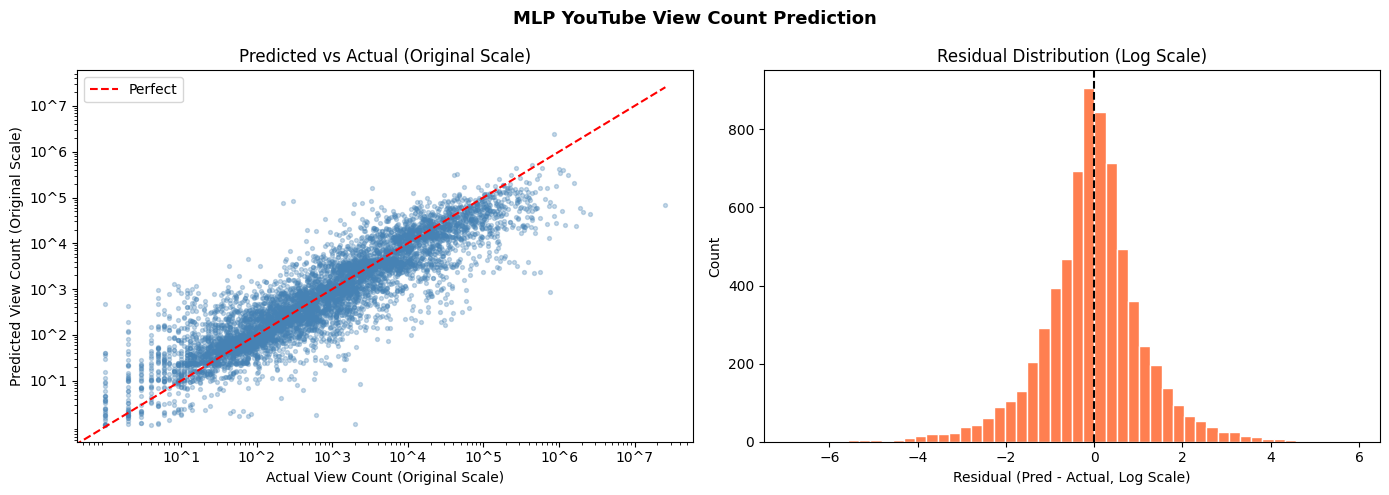

Plot saved as prediction_analysis.png


In [13]:
import matplotlib.pyplot as plt

# Use original scale predictions and labels
preds_np = preds_org.numpy()
labels_np = labels_org.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(labels_np, preds_np, alpha=0.3, s=8, color='steelblue')

# Set log scale for both axes with base 10
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Define tick marks for powers of 10
ticks = [10**i for i in range(1, int(np.log10(max(labels_np.max(), preds_np.max()))) + 1)]
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_xticklabels([f'10^{int(np.log10(t))}' for t in ticks])
axes[0].set_yticklabels([f'10^{int(np.log10(t))}' for t in ticks])

mn, mx = min(labels_np.min(), preds_np.min()), max(labels_np.max(), preds_np.max())
# Add a perfect prediction line (y=x) in log space
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')

axes[0].set_xlabel('Actual View Count (Original Scale)')
axes[0].set_ylabel('Predicted View Count (Original Scale)')
axes[0].set_title('Predicted vs Actual (Original Scale)')
axes[0].legend()

# Residual distribution (still using log scale residuals as defined before)
residuals = all_preds.numpy() - all_labels.numpy() # Keep residuals on log scale for this plot
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (Pred - Actual, Log Scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (Log Scale)')

plt.suptitle('MLP YouTube View Count Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as prediction_analysis.png')
